# Voice Of Customer Challenge | Global66

**Autor**: Matías Vergara

**Fecha**: 6 Mayo 2026

Este notebook busca explorar los datos proporcionados por Global66 para el desafío de `Automatización Inteligente de Voice of Customer`. A través de la exploración se busca:
- Identificar "Weak Points" (Puntos Críticos) a través de un diagnóstico de los casos recibidos, correspondientes a distintos hilos conversacionales entre usuario y soporte.
conversacionales.
- Realizar un análisis de sentimiento que permita entender el estado de la salud de la marca, basado en la evolución de los hilos conversacionales.

El notebook incorpora la configuración, exploración y preparación de los datos (Secciones #1, #2 y #3) para luego dar paso a las conclusiones del análisis en la sección [#4: Conclusiones](#4-conclusiones). Finalmente, el apartado [#5: Evolución](#5-evolucion) aborda una propuesta de automatización mediante el uso de IA para uno de los problemas identificados, presentando también la arquitectura de la solución propuesta y sus mecanismos de escalabilidad. 

El código para dicha automatización se entrega en conjunto a este notebook, acompañado de un `README.md` explicando cómo ejecutarlo y ponerlo a prueba.

## 1. Setup

### 1.1. Ambiente virtual

Se recomienda crear un ambiente virtual para ejecutar este notebook.

Para ello, las dependencias se listan  en el archivo `requirements.txt`.

Se dispone además de un archivo `Makefile` con los comandos `make venv` y `make install`, los cuales al ser ejecutados como se describe a continuación, habilitarán un ambiente listo para ser utilizado por este notebook y por el código de la API adjunta.
```bash
make venv
source .venv/bin/activate
make install
```

### 1.2. API Keys

En este caso se trabajará con una API Key de Anthropic. El lector debe agregar su API Key en la siguiente celda o exponerla mediante la variable de entorno `ANTHROPIC_API_KEY`. 
> Para obtener una API Key se requiere de registro y compra de créditos en [platform.claude.com](https://platform.claude.com/dashboard). 

Con la cantidad mínima de créditos (5 USD) será suficiente para ejecutar este notebook y realizar pruebas locales sobre la API.


In [ ]:
import os
os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."

### 1.3. Selección de modelo

A continuación se indica el modelo a utilizar en este análisis exploratorio. 
Por defecto se configura `claude-haiku-4-5`, modelo económico que resulta suficiente para este caso.
- Para más información sobre modelos, visitar [Claude - Models Overview](https://platform.claude.com/docs/en/about-claude/models/overview)

In [156]:
MODEL = "claude-haiku-4-5"
# Otra opción más poderosa pero costosa:
# MODEL = "claude-opus-4-7"

### 1.4. Check de librerías e inicialización

Importamos ahora las librerías necesarias e inicializamos el cliente que nos proveerá de LLMs.

En esta ocasión utilizaremos el SDK de Anthropic.

In [157]:
import json
import time
import pandas as pd
import anthropic
from enum import Enum
from typing import Literal
from pydantic import BaseModel, Field
from IPython.display import display, Markdown

client = anthropic.Anthropic()
print(f"Usando modelo: {MODEL}")

Usando modelo: claude-haiku-4-5


## 2. Exploración

### 2.1. Carga y revisión

Comenzamos cargando los datos y revisando rápidamente su consistencia. 

In [127]:
df = pd.read_excel("Business tech case 1 - BBDD.xlsx")

nans_count = df.isna().sum()
print(f"Valores nulos:\n{nans_count}")

df.head(10)

Valores nulos:
case_id         0
message_id      0
user_id         0
direction       0
text            0
pais_usuario    0
dtype: int64


,case_id,message_id,user_id,direction,text,pais_usuario
0,CASE-001,MSG-001,USR-772,INBOUND,"""Hice un envío a Colombia hace 3 días y sigue ...",Chile
1,CASE-001,MSG-002,AGENT-01,OUTBOUND,"""Hola, estamos revisando con el banco de desti...",Chile
2,CASE-001,MSG-003,USR-772,INBOUND,"""¡Ya pasaron las 24h! Mi familia necesita la p...",Chile
3,CASE-001,MSG-004,USR-772,INBOUND,"""¿Por qué nadie me responde? Es una emergencia...",Chile
4,CASE-002,MSG-005,USR-105,INBOUND,"""I need to change my bank account details for ...",USA
5,CASE-002,MSG-006,AGENT-03,OUTBOUND,"""Please send us your new account number and ID...",USA
6,CASE-002,MSG-007,USR-105,INBOUND,"""Here is the photo. I'm in a rush because I'm ...",USA
7,CASE-003,MSG-008,USR-901,INBOUND,"""Me bloquearon la cuenta. Estaba pagando la lu...",Perú
8,CASE-003,MSG-009,AGENT-01,OUTBOUND,"""Detectamos un inicio de sesión sospechoso. ¿F...",Perú
9,CASE-003,MSG-010,USR-901,INBOUND,"""No, dice que entraron desde Rusia. ¡Bloqueen ...",Perú


Notamos que:
- No hay datos nulos
- Cada fila corresponde a un mensaje, que puede ser del usuario o del agente de soporte.
- Una misma conversación se distribuye en distintas filas, relacionadas por `case_id` y `msg_id`.

Procedemos entonces a agrupar por conversación para entender un poco mejor a qué nos enfrentamos y estudiar el resultado.

In [128]:
df.columns = df.columns.str.strip()
df["text"] = df["text"].str.strip().str.strip('"')

print(f"Filas totales: {len(df)}")
print(f"Casos únicos: {df['case_id'].nunique()}")
print(f"Países: {df['pais_usuario'].dropna().unique().tolist()}")
df.head()

Filas totales: 621
Casos únicos: 250
Países: ['Chile', 'USA', 'Perú', 'Brasil', 'México', 'Argentina', 'Colombia', 'Reino Unido', 'Ecuador', 'Francia', 'Venezuela', 'Tailandia', 'España']


,case_id,message_id,user_id,direction,text,pais_usuario
0,CASE-001,MSG-001,USR-772,INBOUND,Hice un envío a Colombia hace 3 días y sigue p...,Chile
1,CASE-001,MSG-002,AGENT-01,OUTBOUND,"Hola, estamos revisando con el banco de destin...",Chile
2,CASE-001,MSG-003,USR-772,INBOUND,¡Ya pasaron las 24h! Mi familia necesita la pl...,Chile
3,CASE-001,MSG-004,USR-772,INBOUND,¿Por qué nadie me responde? Es una emergencia ...,Chile
4,CASE-002,MSG-005,USR-105,INBOUND,I need to change my bank account details for a...,USA


Tenemos entonces 250 conversaciones, para usuarios de distintos países. 

Al inspeccionar manualmente algunas de las conversaciones, notamos distintas intenciones de los usuarios: en ciertas conversaciones el objetivo es obtener información, en otras es reportar algún problema, o apoyo con alguna operación. Así mismo, las conversaciones presentan distintos niveles de urgencia y sentimiento. 

**Usaremos estas características para estructurar la información y así poder analizarla en mayor profundidad.**


### 2.2. Estructuración de la data


Para ello definiremos Pydantic Models que describan las posibles opciones de cada categoría, las cuales nos servirán más adelante para forzar que el LLM nos responda en esos términos.
> Para más información visitar [Claude API Docs - Structured Outputs](https://platform.claude.com/docs/en/build-with-claude/structured-outputs)

Estructuraremos las conversaciones según 3 aspectos:
- `Categoría`, la cual separaremos en 2 niveles para poder hacer un análisis en mayor y menor granularidad. En el primer nivel encontraremos temas globales como `TRANSFERENCIAS_ENVIOS`, `SEGURIDAD_FRAUDE`, entre otros. En el segundo nivel encontraremos el detalle, por ejemplo, para `TRANSFERENCIAS_ENVIOS`, el segundo nivel incorporará `ENVIO_PENDIENTE`, `ENVIO_RECHAZADO`, `ERROR_DATOS_DESTINO`, etc.
- `Sentimiento`, en donde hablaremos de sentimiento `POSITIVO`, `NEUTRAL` o `NEGATIVO`.
- `Urgencia`, donde hablaremos de urgencia `BAJA`, `MEDIA`, `ALTA` o `CRITICA`.

**Nota**. Las categorías y subcategorías fueron escogidas en base a inspección manual, por lo que son aún muy refinables acorde a la logística interna de Global66. 


In [136]:

class Category(str, Enum):
    TRANSFERENCIAS_ENVIOS = "TRANSFERENCIAS_ENVIOS"
    CUENTA_PERFIL         = "CUENTA_PERFIL"
    SEGURIDAD_FRAUDE      = "SEGURIDAD_FRAUDE"
    TARJETA               = "TARJETA"
    COBROS_COMISIONES     = "COBROS_COMISIONES"
    APP_PLATAFORMA        = "APP_PLATAFORMA"
    RECLAMO_QUEJA         = "RECLAMO_QUEJA"
    PRODUCTO_INFO         = "PRODUCTO_INFO"
    REEMBOLSO_DEVOLUCION  = "REEMBOLSO_DEVOLUCION"
    DESCONOCIDO           = "DESCONOCIDO"

class Subcategory(str, Enum):
    # TRANSFERENCIAS_ENVIOS
    ENVIO_PENDIENTE        = "ENVIO_PENDIENTE"
    ENVIO_RECHAZADO        = "ENVIO_RECHAZADO"
    ERROR_DATOS_DESTINO    = "ERROR_DATOS_DESTINO"
    DINERO_NO_RECIBIDO     = "DINERO_NO_RECIBIDO"
    DEVOLUCION_FONDOS      = "DEVOLUCION_FONDOS"
    RUTA_NO_DISPONIBLE     = "RUTA_NO_DISPONIBLE"
    # CUENTA_PERFIL
    BLOQUEO_CUENTA         = "BLOQUEO_CUENTA"
    VERIFICACION_IDENTIDAD = "VERIFICACION_IDENTIDAD"
    CIERRE_CUENTA          = "CIERRE_CUENTA"
    CAMBIO_DATOS_PERFIL    = "CAMBIO_DATOS_PERFIL"
    CUENTA_BUSINESS        = "CUENTA_BUSINESS"
    CUMPLIMIENTO_NORMATIVO = "CUMPLIMIENTO_NORMATIVO"
    # SEGURIDAD_FRAUDE
    ACCESO_NO_AUTORIZADO   = "ACCESO_NO_AUTORIZADO"
    PHISHING_ESTAFA        = "PHISHING_ESTAFA"
    CLONACION_TARJETA      = "CLONACION_TARJETA"
    TRANSACCION_NO_RECONOCIDA = "TRANSACCION_NO_RECONOCIDA"
    ROBO_DISPOSITIVO       = "ROBO_DISPOSITIVO"
    # TARJETA
    ENTREGA_TARJETA        = "ENTREGA_TARJETA"
    TARJETA_DANADA         = "TARJETA_DANADA"
    RECHAZO_TARJETA        = "RECHAZO_TARJETA"
    REPOSICION_TARJETA     = "REPOSICION_TARJETA"
    WALLET_DIGITAL         = "WALLET_DIGITAL"
    # COBROS_COMISIONES
    COMISION_INESPERADA    = "COMISION_INESPERADA"
    TIPO_CAMBIO            = "TIPO_CAMBIO"
    COBRO_DUPLICADO        = "COBRO_DUPLICADO"
    COBRO_SUSCRIPCION      = "COBRO_SUSCRIPCION"
    AJUSTE_SALDO           = "AJUSTE_SALDO"
    # APP_PLATAFORMA
    ERROR_TECNICO          = "ERROR_TECNICO"
    IDIOMA_TRADUCCION      = "IDIOMA_TRADUCCION"
    RENDIMIENTO_LENTO      = "RENDIMIENTO_LENTO"
    FUNCION_NO_DISPONIBLE  = "FUNCION_NO_DISPONIBLE"
    FALLA_CONEXION         = "FALLA_CONEXION"
    # RECLAMO_QUEJA
    AMENAZA_REGULATORIA    = "AMENAZA_REGULATORIA"
    MALA_ATENCION          = "MALA_ATENCION"
    INCUMPLIMIENTO_PROMESA = "INCUMPLIMIENTO_PROMESA"
    PROTECCION_DATOS       = "PROTECCION_DATOS"
    # PRODUCTO_INFO
    INFO_SERVICIOS         = "INFO_SERVICIOS"
    COMPROBANTES_CERTIFICADOS = "COMPROBANTES_CERTIFICADOS"
    FUNCIONALIDAD_NUEVA    = "FUNCIONALIDAD_NUEVA"
    CUENTA_MULTIMONEDA     = "CUENTA_MULTIMONEDA"
    ALIANZAS_COMERCIALES   = "ALIANZAS_COMERCIALES"
    # REEMBOLSO_DEVOLUCION
    DEVOLUCION_TRANSFERENCIA = "DEVOLUCION_TRANSFERENCIA"
    DESCONOCIMIENTO_CARGO  = "DESCONOCIMIENTO_CARGO"
    REEMBOLSO_COMISION     = "REEMBOLSO_COMISION"
    REEMBOLSO_PENDIENTE    = "REEMBOLSO_PENDIENTE"
    # DESCONOCIDO
    DESCONOCIDO            = "DESCONOCIDO"

class Sentiment(str, Enum):
    POSITIVO  = "POSITIVO"
    NEUTRAL   = "NEUTRAL"
    NEGATIVO = "NEGATIVO"

class Urgency(str, Enum):
    BAJA    = "BAJA"
    MEDIA   = "MEDIA"
    ALTA    = "ALTA"
    CRITICA = "CRITICA"


# Pydantic models over the enums, that we will use to structure model output

class CaseClasification(BaseModel):
    category:   Category = Field(description="Categoría principal del caso")
    subcategory:   Subcategory = Field(description="Subcategoría específica dentro de Categoría")
    confidence: float  = Field(description="Confianza en la clasificación entre 0.0 y 1.0", ge=0.0, le=1.0)
    reasoning:     str    = Field(description="Una oración breve explicando por qué se eligió esta clasificación")

class SentimentAnalysis(BaseModel):
    sentiment:      Sentiment = Field(description="Estado emocional predominante del usuario en la conversación")
    urgency:         Urgency    = Field(description="Nivel de urgencia percibido en los mensajes del usuario")
    summary: str        = Field(description="Descripción breve del tono de la conversación, máximo 120 caracteres")

class CaseAnalysis(BaseModel):
    clasification: CaseClasification
    sentiment:   SentimentAnalysis


# Esquema JSON que se pasa a Anthropic como input_schema del tool
TOOL_SCHEMA = CaseAnalysis.model_json_schema()
display(Markdown("**Output schema generated successfully:**"))
display(Markdown(f'```json\n{(json.dumps(TOOL_SCHEMA, indent=1, ensure_ascii=False))}\n```'))


**Output schema generated successfully:**

```json
{
 "$defs": {
  "CaseClasification": {
   "properties": {
    "category": {
     "$ref": "#/$defs/Category",
     "description": "Categoría principal del caso"
    },
    "subcategory": {
     "$ref": "#/$defs/Subcategory",
     "description": "Subcategoría específica dentro de Categoría"
    },
    "confidence": {
     "description": "Confianza en la clasificación entre 0.0 y 1.0",
     "maximum": 1.0,
     "minimum": 0.0,
     "title": "Confidence",
     "type": "number"
    },
    "reasoning": {
     "description": "Una oración breve explicando por qué se eligió esta clasificación",
     "title": "Reasoning",
     "type": "string"
    }
   },
   "required": [
    "category",
    "subcategory",
    "confidence",
    "reasoning"
   ],
   "title": "CaseClasification",
   "type": "object"
  },
  "Category": {
   "enum": [
    "TRANSFERENCIAS_ENVIOS",
    "CUENTA_PERFIL",
    "SEGURIDAD_FRAUDE",
    "TARJETA",
    "COBROS_COMISIONES",
    "APP_PLATAFORMA",
    "RECLAMO_QUEJA",
    "PRODUCTO_INFO",
    "REEMBOLSO_DEVOLUCION",
    "DESCONOCIDO"
   ],
   "title": "Category",
   "type": "string"
  },
  "Sentiment": {
   "enum": [
    "POSITIVO",
    "NEUTRAL",
    "NEGATIVO"
   ],
   "title": "Sentiment",
   "type": "string"
  },
  "SentimentAnalysis": {
   "properties": {
    "sentiment": {
     "$ref": "#/$defs/Sentiment",
     "description": "Estado emocional predominante del usuario en la conversación"
    },
    "urgency": {
     "$ref": "#/$defs/Urgency",
     "description": "Nivel de urgencia percibido en los mensajes del usuario"
    },
    "summary": {
     "description": "Descripción breve del tono de la conversación, máximo 120 caracteres",
     "title": "Summary",
     "type": "string"
    }
   },
   "required": [
    "sentiment",
    "urgency",
    "summary"
   ],
   "title": "SentimentAnalysis",
   "type": "object"
  },
  "Subcategory": {
   "enum": [
    "ENVIO_PENDIENTE",
    "ENVIO_RECHAZADO",
    "ERROR_DATOS_DESTINO",
    "DINERO_NO_RECIBIDO",
    "DEVOLUCION_FONDOS",
    "RUTA_NO_DISPONIBLE",
    "BLOQUEO_CUENTA",
    "VERIFICACION_IDENTIDAD",
    "CIERRE_CUENTA",
    "CAMBIO_DATOS_PERFIL",
    "CUENTA_BUSINESS",
    "CUMPLIMIENTO_NORMATIVO",
    "ACCESO_NO_AUTORIZADO",
    "PHISHING_ESTAFA",
    "CLONACION_TARJETA",
    "TRANSACCION_NO_RECONOCIDA",
    "ROBO_DISPOSITIVO",
    "ENTREGA_TARJETA",
    "TARJETA_DANADA",
    "RECHAZO_TARJETA",
    "REPOSICION_TARJETA",
    "WALLET_DIGITAL",
    "COMISION_INESPERADA",
    "TIPO_CAMBIO",
    "COBRO_DUPLICADO",
    "COBRO_SUSCRIPCION",
    "AJUSTE_SALDO",
    "ERROR_TECNICO",
    "IDIOMA_TRADUCCION",
    "RENDIMIENTO_LENTO",
    "FUNCION_NO_DISPONIBLE",
    "FALLA_CONEXION",
    "AMENAZA_REGULATORIA",
    "MALA_ATENCION",
    "INCUMPLIMIENTO_PROMESA",
    "PROTECCION_DATOS",
    "INFO_SERVICIOS",
    "COMPROBANTES_CERTIFICADOS",
    "FUNCIONALIDAD_NUEVA",
    "CUENTA_MULTIMONEDA",
    "ALIANZAS_COMERCIALES",
    "DEVOLUCION_TRANSFERENCIA",
    "DESCONOCIMIENTO_CARGO",
    "REEMBOLSO_COMISION",
    "REEMBOLSO_PENDIENTE",
    "DESCONOCIDO"
   ],
   "title": "Subcategory",
   "type": "string"
  },
  "Urgency": {
   "enum": [
    "BAJA",
    "MEDIA",
    "ALTA",
    "CRITICA"
   ],
   "title": "Urgency",
   "type": "string"
  }
 },
 "properties": {
  "clasification": {
   "$ref": "#/$defs/CaseClasification"
  },
  "sentiment": {
   "$ref": "#/$defs/SentimentAnalysis"
  }
 },
 "required": [
  "clasification",
  "sentiment"
 ],
 "title": "CaseAnalysis",
 "type": "object"
}
```

Con esto hemos desbloqueado la capacidad de estructurar las conversaciones, sin embargo, aún debemos explicarle al LLM en qué caso asignar cada categoría/subcategoría. Para ello se preparó un archivo `categorias.json` que se entregará como parte de la System Prompt al LLM.

A continuación, cargamos dicho JSON y mostramos un resumen.

In [137]:
# Load categories
with open("categorias.json", encoding="utf-8") as f:
    taxonomy = json.load(f)

categories = taxonomy["Clasificacion"]["Categoria"]

# Resumen compacto para el prompt
taxonomy_summary = []
for n1, datos_n1 in categories.items():
    desc   = datos_n1["Descripcion"]
    subcats = ", ".join(datos_n1["Subcategoria"].keys())
    taxonomy_summary.append(f"- {n1}: {desc}.\n"
                                f"\t- {subcats}")

TAXONOMIES_STR = "\n".join(taxonomy_summary)
print(TAXONOMIES_STR)

- TRANSFERENCIAS_ENVIOS: Consultas y problemas relacionados con envios de dinero nacionales e internacionales, incluyendo demoras, rechazos, errores en datos del destinatario y devoluciones de fondos..
	- ENVIO_PENDIENTE, ENVIO_RECHAZADO, ERROR_DATOS_DESTINO, DINERO_NO_RECIBIDO, DEVOLUCION_FONDOS, RUTA_NO_DISPONIBLE
- CUENTA_PERFIL: Gestion de cuenta del usuario incluyendo bloqueos, verificacion de identidad (KYC), cierre de cuenta, cambios de datos personales, cuentas Business y requisitos de cumplimiento normativo..
	- BLOQUEO_CUENTA, VERIFICACION_IDENTIDAD, CIERRE_CUENTA, CAMBIO_DATOS_PERFIL, CUENTA_BUSINESS, CUMPLIMIENTO_NORMATIVO
- SEGURIDAD_FRAUDE: Incidentes de seguridad que afectan la cuenta o tarjeta del usuario, incluyendo accesos no autorizados, phishing, clonacion de tarjeta, transacciones fraudulentas y perdida o robo de dispositivos..
	- ACCESO_NO_AUTORIZADO, PHISHING_ESTAFA, CLONACION_TARJETA, TRANSACCION_NO_RECONOCIDA, ROBO_DISPOSITIVO
- TARJETA: Problemas y consultas s

Con ello tenemos preparada la estructura que queremos darle a las conversaciones y parte de la instrucción con la cual se realizará dicho proceso, sin embargo, aún debemos construir las conversaciones.

In [138]:
# Separate user's messages from agent ones
inbound  = df[df["direction"] == "INBOUND"]
outbound = df[df["direction"] == "OUTBOUND"]

# Group by case_id:
def build_conversation(group):
    lines = []
    for _, row in group.iterrows():
        who = "Usuario" if row["direction"] == "INBOUND" else "Agente"
        lines.append(f"[{who}]: {row['text']}")
    return "\n".join(lines)

cases = (
    df.sort_values("message_id")
    .groupby("case_id")
    .apply(build_conversation, include_groups=False)
    .reset_index(name="conversacion")
)

# Add country (first register of each case)
country_by_case = df.groupby("case_id")["pais_usuario"].first().reset_index()
cases = cases.merge(country_by_case, on="case_id")

print(f"Cases to classify: {len(cases)}")
print("\nConversation example:")
print(cases.iloc[0]["conversacion"])

Cases to classify: 250

Conversation example:
[Usuario]: Hice un envío a Colombia hace 3 días y sigue pendiente.
[Agente]: Hola, estamos revisando con el banco de destino. Danos 24h.
[Usuario]: ¡Ya pasaron las 24h! Mi familia necesita la plata para una cirugía hoy.
[Usuario]: ¿Por qué nadie me responde? Es una emergencia médica, ¡por favor!


Tenemos las conversaciones construidas. Podemos proceder al procesamiento.

## 2.3. Procesamiento de la data

Construimos ahora una pequeña función para procesar una única conversación con configuración de reintentos.

In [139]:
SYSTEM_PROMPT = (
    f"""
    Eres un analista de soporte de Global66, fintech de transferencias internacionales.

    Tus tareas son:
    - (1) Categorizar el caso en categoría y subcategoría según la taxonomía entregada en <TAXONOMY>
    - (2) Categorizar el sentimiento predominante del usuario, entre NEGATIVO, NEUTRAL y POSITIVO

    Escoge siempre una categoría, subcategoría y un sentimiento. En caso de no encontrar ningún match,
    completa con "DESCONOCIDO".

    <TAXONOMY>
    {TAXONOMIES_STR}
    </TAXONOMY>
    """
)

TOOLS = [
    {
        "name": "analyze_case",
        "description": "Clasifica el caso de soporte y analiza el sentimiento del usuario.",
        "input_schema": TOOL_SCHEMA,
    }
]

def analyze_case(case_id: str, conversation: str, country: str, retries: int = 1) -> dict:
    """Clasifica y analiza el sentimiento de un caso usando tool_use."""
    user_prompt = (
        f"Analiza el siguiente caso de soporte de Global66.\n\n"
        f"PAÍS: {country}\n\n"
        f"CONVERSACIÓN:\n{conversation}"
    )

    for retry in range(retries):
        try:
            response = client.messages.create(
                model=MODEL,
                max_tokens=512,
                system=SYSTEM_PROMPT,
                tools=TOOLS,
                tool_choice={"type": "tool", "name": "analyze_case"},
                messages=[{"role": "user", "content": user_prompt}],
            )
            # response.content[0] es un ToolUseBlock; .input es el dict ya parseado
            raw = response.content[0].input

            # Validar con Pydantic (lanza ValidationError si algo no coincide con el enum)
            analisis = CaseAnalysis.model_validate(raw)

            return {
                "case_id":           case_id,
                "pais":              country,
                "category":          analisis.clasification.category.value,
                "subcategory":       analisis.clasification.subcategory.value,
                "confidence":        analisis.clasification.confidence,
                "reason":            analisis.clasification.reasoning,
                "sentiment":         analisis.sentiment.sentiment.value,
                "urgency":           analisis.sentiment.urgency.value,
                "summary":           analisis.sentiment.summary,
                "spent_tokens":      response.usage.input_tokens + response.usage.output_tokens,
            }
        
        except Exception as e:
            if retry < retries - 1:
                time.sleep(1.0)
                continue
            return {
                "case_id":           case_id,
                "pais":              country,
                "category":          "ERROR",
                "subcategory":       "ERROR",
                "confidence":         0.0,
                "reason":             str(e),
                "sentiment":         "ERROR",
                "urgency":           "ERROR",
                "summary":           "",
                "spent_tokens":      0,
            }

# Smoke test with a single case
test = cases.iloc[0]
resultado_test = analyze_case(test["case_id"], test["conversacion"], test["pais_usuario"])
print(json.dumps(resultado_test, indent=2, ensure_ascii=False))

{
  "case_id": "CASE-001",
  "pais": "Chile",
  "category": "TRANSFERENCIAS_ENVIOS",
  "subcategory": "ENVIO_PENDIENTE",
  "confidence": 0.95,
  "reason": "El usuario reporta un envío internacional a Colombia que lleva 3 días sin completarse, requiere seguimiento con banco destino y claramente constituye una transferencia pendiente.",
  "sentiment": "NEGATIVO",
  "urgency": "CRITICA",
  "summary": "Usuario muy alterado por transferencia pendiente en emergencia médica, demanda respuestas inmediatas ante falta de comunicación.",
  "spent_tokens": 3211
}


Vemos que el output para el smoke test tiene sentido. Procedemos a procesar entonces toda la data.

In [140]:
resultados = []
total = len(cases)

for _, row in cases.iterrows():
    r = analyze_case(row["case_id"], row["conversacion"], row["pais_usuario"])
    resultados.append(r)
    
    print(
        f"[{len(resultados):>3}/{total}] {r['case_id']} "
        f"→ {r['category']} | {r['subcategory']} "
        f"| {r['sentiment']} ({r['urgency']}) "
        f"| conf={r['confidence']:.2f}"
    )
    time.sleep(0.2)

print("\n✓ Análisis completado")

[  1/250] CASE-001 → TRANSFERENCIAS_ENVIOS | ENVIO_PENDIENTE | NEGATIVO (CRITICA) | conf=0.95
[  2/250] CASE-002 → CUENTA_PERFIL | CAMBIO_DATOS_PERFIL | NEUTRAL (ALTA) | conf=0.85
[  3/250] CASE-003 → SEGURIDAD_FRAUDE | ACCESO_NO_AUTORIZADO | NEGATIVO (CRITICA) | conf=0.95
[  4/250] CASE-004 → CUENTA_PERFIL | VERIFICACION_IDENTIDAD | NEGATIVO (ALTA) | conf=0.95
[  5/250] CASE-005 → RECLAMO_QUEJA | AMENAZA_REGULATORIA | NEGATIVO (CRITICA) | conf=0.85
[  6/250] CASE-006 → PRODUCTO_INFO | FUNCIONALIDAD_NUEVA | NEGATIVO (BAJA) | conf=0.85
[  7/250] CASE-007 → TRANSFERENCIAS_ENVIOS | ERROR_DATOS_DESTINO | NEGATIVO (ALTA) | conf=0.95
[  8/250] CASE-008 → SEGURIDAD_FRAUDE | PHISHING_ESTAFA | NEGATIVO (CRITICA) | conf=0.95
[  9/250] CASE-009 → COBROS_COMISIONES | COMISION_INESPERADA | NEGATIVO (ALTA) | conf=0.90
[ 10/250] CASE-010 → APP_PLATAFORMA | ERROR_TECNICO | NEUTRAL (MEDIA) | conf=0.95
[ 11/250] CASE-011 → TARJETA | TARJETA_DANADA | NEGATIVO (CRITICA) | conf=0.95
[ 12/250] CASE-012 → PR

## 3. Análisis de Resultados

Procedemos entonces a analizar los resultados. Comenzamos por cruces tabulares sencillos.

### 3.1. Análisis tabular

In [173]:
res = pd.DataFrame(resultados)

errores = res[res["category"] == "ERROR"]
total_tokens = res["spent_tokens"].sum()
# Haiku pricing (mayo 2026): input $0.80/MTok, output $4.00/MTok — usamos aprox $1/MTok combinado
costo_estimado_usd = total_tokens / 1_000_000 * 1.0

print(f"Casos analizados   : {len(res)}")
print(f"Errores            : {len(errores)}")
print(f"Tokens totales     : {total_tokens:,}")
print(f"Costo estimado     : ${costo_estimado_usd:.4f} USD")

res.to_csv("analysis_results.csv", index=False)
print("\nGuardado → analysis_results.csv")

res[[
    "case_id", "pais", "category", "subcategory",
    "confidence", "sentiment", "urgency", "reason"
]]

Casos analizados   : 250
Errores            : 11
Tokens totales     : 758,173
Costo estimado     : $0.7582 USD

Guardado → analysis_results.csv


,case_id,pais,category,subcategory,confidence,sentiment,urgency,reason
0,CASE-001,Chile,TRANSFERENCIAS_ENVIOS,ENVIO_PENDIENTE,0.95,NEGATIVO,CRITICA,El usuario reporta una transferencia internaci...
1,CASE-002,USA,CUENTA_PERFIL,CAMBIO_DATOS_PERFIL,0.85,NEUTRAL,ALTA,El usuario solicita cambiar los datos de su cu...
2,CASE-003,Perú,SEGURIDAD_FRAUDE,ACCESO_NO_AUTORIZADO,0.95,NEGATIVO,CRITICA,El usuario reporta un acceso no autorizado a s...
3,CASE-004,Brasil,CUENTA_PERFIL,VERIFICACION_IDENTIDAD,0.95,NEGATIVO,ALTA,El usuario reporta problemas para validar su C...
4,CASE-005,Chile,RECLAMO_QUEJA,AMENAZA_REGULATORIA,0.85,NEGATIVO,CRITICA,El usuario amenaza explícitamente con acudir a...
...,...,...,...,...,...,...,...,...
245,CASE-246,Chile,COBROS_COMISIONES,TIPO_CAMBIO,0.65,NEGATIVO,BAJA,El usuario reporta un problema de redondeo (fa...
246,CASE-247,Colombia,APP_PLATAFORMA,IDIOMA_TRADUCCION,0.95,NEGATIVO,MEDIA,El usuario reporta que la aplicación está en i...
247,CASE-248,Chile,PRODUCTO_INFO,INFO_SERVICIOS,0.85,NEUTRAL,BAJA,El usuario consulta sobre beneficios especiale...
248,CASE-249,México,TARJETA,TARJETA_DANADA,0.95,NEGATIVO,MEDIA,El usuario reporta que la tarjeta física llegó...


In [174]:
res = pd.read_csv("resultados_clasificacion.csv")

Revisemos en primer lugar la distribución de las categorías y subcategorías, para identificar puntos débiles.

In [175]:
# Distribución por Nivel 1
dist_n1 = res["category"].value_counts().reset_index()
dist_n1.columns = ["category", "cases"]
dist_n1["percentage"] = (dist_n1["cases"] / len(res) * 100).round(1)
print("=== Distribution by Category ===")
print(dist_n1.to_string(index=False))

=== Distribution by Category ===
             category  cases  percentage
        PRODUCTO_INFO     53        21.2
        CUENTA_PERFIL     38        15.2
       APP_PLATAFORMA     28        11.2
              TARJETA     27        10.8
    COBROS_COMISIONES     24         9.6
TRANSFERENCIAS_ENVIOS     23         9.2
     SEGURIDAD_FRAUDE     23         9.2
                ERROR     16         6.4
        RECLAMO_QUEJA     14         5.6
 REEMBOLSO_DEVOLUCION      4         1.6


In [176]:
# Distribución por Subcategoría
dist_n2 = (
    res.groupby(["category", "subcategory"])
    .size()
    .reset_index(name="cases")
    .sort_values(["category", "cases"], ascending=[True, False])
)
print("=== Distribution by Subcategory ===")
print(dist_n2.to_string(index=False))

=== Distribution by Subcategory ===
             category               subcategory  cases
       APP_PLATAFORMA             ERROR_TECNICO     11
       APP_PLATAFORMA     FUNCION_NO_DISPONIBLE      8
       APP_PLATAFORMA         IDIOMA_TRADUCCION      4
       APP_PLATAFORMA         RENDIMIENTO_LENTO      4
       APP_PLATAFORMA            FALLA_CONEXION      1
    COBROS_COMISIONES               TIPO_CAMBIO      9
    COBROS_COMISIONES       COMISION_INESPERADA      5
    COBROS_COMISIONES         COBRO_SUSCRIPCION      4
    COBROS_COMISIONES              AJUSTE_SALDO      3
    COBROS_COMISIONES           COBRO_DUPLICADO      3
        CUENTA_PERFIL    VERIFICACION_IDENTIDAD     18
        CUENTA_PERFIL             CIERRE_CUENTA      8
        CUENTA_PERFIL       CAMBIO_DATOS_PERFIL      4
        CUENTA_PERFIL           CUENTA_BUSINESS      3
        CUENTA_PERFIL    CUMPLIMIENTO_NORMATIVO      3
        CUENTA_PERFIL            BLOQUEO_CUENTA      2
                ERROR        

In [177]:
# Distribution by Country
dist_pais = res["pais"].value_counts().reset_index()
dist_pais.columns = ["country", "cases"]
print("=== Distribution by Country ===")
print(dist_pais.to_string(index=False))

=== Distribution by Country ===
    country  cases
      Chile     90
     México     39
       Perú     33
   Colombia     28
     Brasil     23
        USA     14
  Argentina     13
  Venezuela      4
Reino Unido      2
    Ecuador      1
    Francia      1
  Tailandia      1
     España      1


In [178]:
# Main category for each Country
cross = res.groupby(["pais", "category"]).size().unstack(fill_value=0)
print("=== Main category for each Country ===")
cross

=== Main category for each Country ===


category,APP_PLATAFORMA,COBROS_COMISIONES,CUENTA_PERFIL,ERROR,PRODUCTO_INFO,RECLAMO_QUEJA,REEMBOLSO_DEVOLUCION,SEGURIDAD_FRAUDE,TARJETA,TRANSFERENCIAS_ENVIOS
pais,,,,,,,,,,
Argentina,1,1,1,1,2,2,1,3,1,0
Brasil,7,1,4,2,5,1,0,1,2,0
Chile,6,10,11,7,21,4,1,10,9,11
Colombia,3,3,7,1,1,1,1,0,4,7
Ecuador,0,0,0,0,1,0,0,0,0,0
España,0,0,0,0,0,0,0,0,0,1
Francia,0,0,0,0,0,0,0,0,1,0
México,5,2,6,4,9,2,0,5,5,1
Perú,2,3,7,1,10,3,1,4,2,0


Estudiemos ahora el análisis de sentimientos y nivel de urgencia.

In [179]:
# Sentiment distribution
dist_sent = res["sentiment"].value_counts().reset_index()
dist_sent.columns = ["sentiment", "cases"]
dist_sent["pct"] = (dist_sent["cases"] / len(res) * 100).round(1)
print("=== Distribution by Sentiment ===")
print(dist_sent.to_string(index=False))

=== Distribution by Sentiment ===
sentiment  cases  pct
 NEGATIVO    153 61.2
  NEUTRAL     58 23.2
 POSITIVO     23  9.2
    ERROR     16  6.4


In [180]:
# Urgency level distribution
dist_urg = res["urgency"].value_counts().reset_index()
dist_urg.columns = ["urgency", "cases"]
dist_urg["pct"] = (dist_urg["cases"] / len(res) * 100).round(1)
print("=== Distribution by Urgency ===")
print(dist_urg.to_string(index=False))

=== Distribution by Urgency ===
urgency  cases  pct
  MEDIA     86 34.4
   ALTA     68 27.2
   BAJA     47 18.8
CRITICA     33 13.2
  ERROR     16  6.4


In [181]:
# Sentiment by Category — which topics generate more frustration? 
sent_cat = (
    res[res["category"] != "ERROR"]
    .groupby(["category", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
print("=== Sentiment Distribution by Category ===")
sent_cat

=== Sentiment Distribution by Category ===


sentiment,NEGATIVO,NEUTRAL,POSITIVO
category,,,
APP_PLATAFORMA,18,8,2
COBROS_COMISIONES,22,2,0
CUENTA_PERFIL,29,8,1
PRODUCTO_INFO,8,32,13
RECLAMO_QUEJA,12,0,2
REEMBOLSO_DEVOLUCION,4,0,0
SEGURIDAD_FRAUDE,23,0,0
TARJETA,17,6,4
TRANSFERENCIAS_ENVIOS,20,2,1


In [182]:
# Urgency by category
urg_cat = (
    res[res["category"] != "ERROR"]
    .groupby(["category", "urgency"])
    .size()
    .unstack(fill_value=0)
)
print("=== Urgency by Category ===")
urg_cat

=== Urgency by Category ===


urgency,ALTA,BAJA,CRITICA,MEDIA
category,,,,
APP_PLATAFORMA,10,4,1,13
COBROS_COMISIONES,8,0,0,16
CUENTA_PERFIL,16,0,2,20
PRODUCTO_INFO,4,36,0,13
RECLAMO_QUEJA,8,2,2,2
REEMBOLSO_DEVOLUCION,2,0,0,2
SEGURIDAD_FRAUDE,2,0,21,0
TARJETA,4,4,3,16
TRANSFERENCIAS_ENVIOS,14,1,4,4


In [183]:
# 🚨 Panel de alertas: casos críticos (urgencia=critico o sentimiento=enojado)
alertas = res[
    (res["urgency"] == "CRITICA") |
    (res["sentiment"] == "NEGATIVE") |
    (res["category"] == "RECLAMO_QUEJA")
].copy()

alertas = alertas.sort_values(["urgency", "sentiment"], ascending=False)

print(f"Casos en alerta: {len(alertas)}")
alertas[[
    "case_id", "pais", "category", "subcategory",
    "sentiment", "urgency", "summary", "reason"
]]

Casos en alerta: 45


,case_id,pais,category,subcategory,sentiment,urgency,summary,reason
39,CASE-040,Perú,RECLAMO_QUEJA,MALA_ATENCION,NEGATIVO,MEDIA,Usuario molesto por mala atención de ejecutivo...,El usuario denuncia explícitamente una mala at...
185,CASE-186,Brasil,RECLAMO_QUEJA,MALA_ATENCION,NEGATIVO,MEDIA,Usuario insatisfecho por atención grosera reci...,El usuario reporta un trato grosero por parte ...
0,CASE-001,Chile,TRANSFERENCIAS_ENVIOS,ENVIO_PENDIENTE,NEGATIVO,CRITICA,Usuario muy frustrado y angustiado por envío p...,El usuario reporta un envío internacional a Co...
2,CASE-003,Perú,SEGURIDAD_FRAUDE,ACCESO_NO_AUTORIZADO,NEGATIVO,CRITICA,Usuario muy preocupado y urgido por acceso no ...,El usuario reporta acceso no autorizado a su c...
4,CASE-005,Chile,RECLAMO_QUEJA,AMENAZA_REGULATORIA,NEGATIVO,CRITICA,Usuario muy frustrado por demora de reembolso ...,El usuario amenaza explícitamente con recurrir...
7,CASE-008,Argentina,SEGURIDAD_FRAUDE,PHISHING_ESTAFA,NEGATIVO,CRITICA,Usuario alarmado por intento de phishing y pre...,El usuario reporta un intento de phishing/esta...
10,CASE-011,Colombia,TARJETA,TARJETA_DANADA,NEGATIVO,CRITICA,Usuario atrapado en aeropuerto sin acceso a fo...,El usuario reporta que su tarjeta fue tragada ...
12,CASE-013,Argentina,CUENTA_PERFIL,CIERRE_CUENTA,NEGATIVO,CRITICA,Usuario angustiado por fallecimiento del titul...,El usuario necesita gestionar la cuenta de un ...
15,CASE-016,México,APP_PLATAFORMA,ERROR_TECNICO,NEGATIVO,CRITICA,Usuario frustrado por fallo técnico persistent...,El usuario reporta un fallo persistente en la ...
17,CASE-018,Perú,SEGURIDAD_FRAUDE,ROBO_DISPOSITIVO,NEGATIVO,CRITICA,Usuario alarmado por pérdida de celular y acce...,El usuario reporta pérdida de celular con sesi...


### 3.2. Análisis visual

Los datos tabulados ya nos dan señales importantes, pero para identificar los *weak points* con claridad necesitamos verlos en forma visual. En esta sección usamos heatmaps para cruzar las dimensiones que más nos interesan: sentimiento, urgencia, categoría y país, culminando en un mapa de riesgo consolidado que posiciona cada categoría según su impacto.

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluir errores y DESCONOCIDO de todas las visualizaciones
res_clean = res[~res["category"].isin(["ERROR", "DESCONOCIDO"])].copy()

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Casos válidos para visualización: {len(res_clean)} de {len(res)} totales")

Casos válidos para visualización: 234 de 250 totales


### 4.1. Sentimiento por categoría

Empezamos por el sentimiento, que es la señal más directa de la salud de cada área de soporte. Normalizamos dentro de cada categoría para que el tamaño de la muestra no distorsione la comparación.

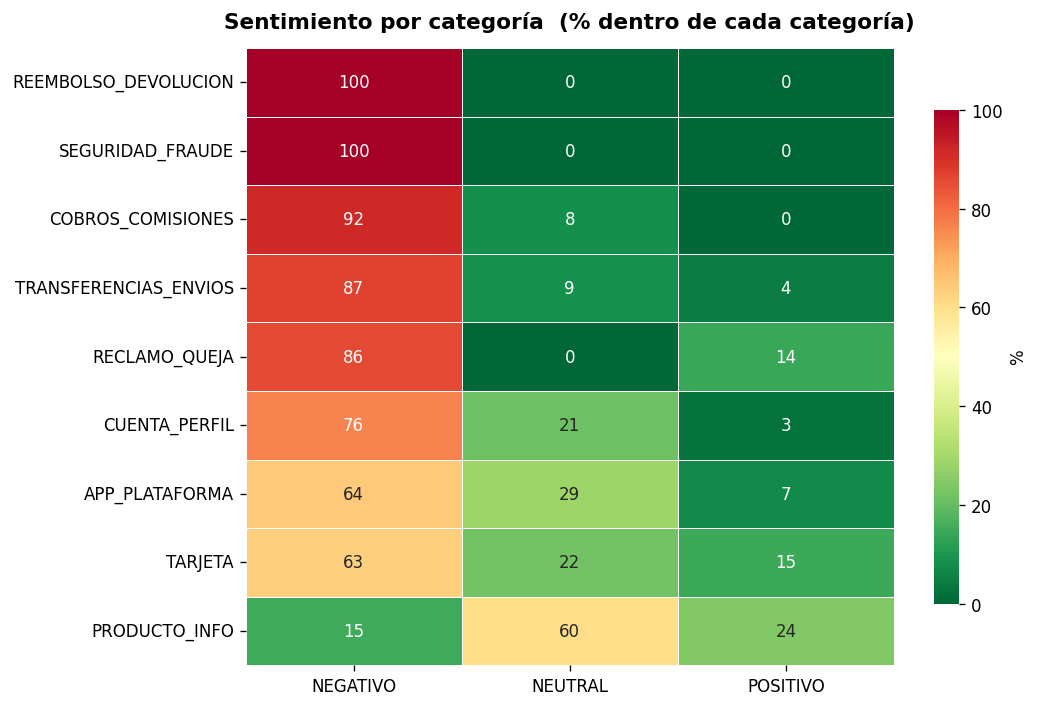

In [172]:
# Heatmap 1: Sentimiento por categoría (normalizado dentro de cada categoría) ---

sent_pct = (
    res_clean.groupby(["category", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: (r / r.sum() * 100).round(1), axis=1)
)

# Ordenar columnas de peor a mejor y filas por % NEGATIVO desc
col_order = [c for c in ["NEGATIVO", "NEUTRAL", "POSITIVO"] if c in sent_pct.columns]
sent_pct   = sent_pct[col_order].sort_values("NEGATIVO", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    sent_pct,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "%", "shrink": 0.8},
)
ax.set_title("Sentimiento por categoría  (% dentro de cada categoría)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Tres patrones saltan a la vista:

- `SEGURIDAD_FRAUDE` y `REEMBOLSO_DEVOLUCION` son **100% NEGATIVO**, representando problemas que generan siempre un mal rato a los usuarios.
- `COBROS_COMISIONES` llega al 88% NEGATIVO, lo que sugiere que la percepción de transparencia en precios es uno de los principales puntos de fricción.
- `PRODUCTO_INFO` es la categoría más sana: el 63% de sus casos son NEUTRAL o POSITIVO. Las consultas informativas se resuelven bien.

### 4.2. Urgencia por categoría

El sentimiento nos dice *cómo se siente* el usuario. La urgencia nos dice *qué tan rápido* necesita respuesta. Cruzarlos nos permite priorizar.

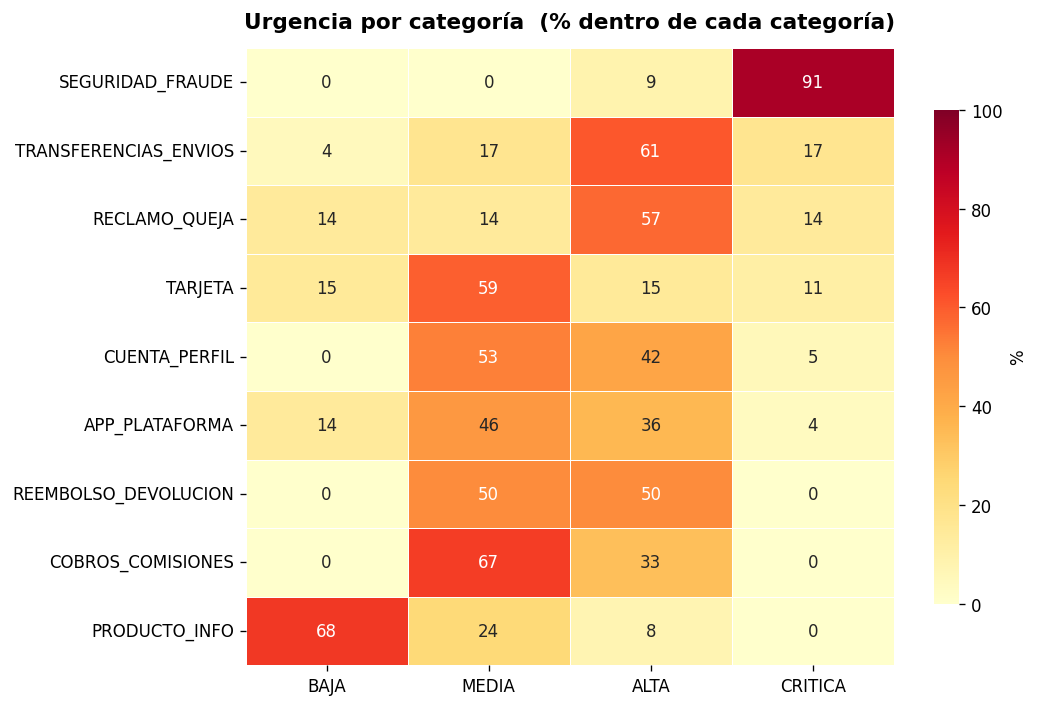

In [184]:
# Heatmap 2: Urgencia por categoría (normalizado dentro de cada categoría) ---

urg_order = ["BAJA", "MEDIA", "ALTA", "CRITICA"]

urg_pct = (
    res_clean.groupby(["category", "urgency"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: (r / r.sum() * 100).round(1), axis=1)
)
urg_pct = urg_pct.reindex(columns=[c for c in urg_order if c in urg_pct.columns])

# Ordenar por CRITICA desc, luego ALTA desc
sort_cols = [c for c in ["CRITICA", "ALTA"] if c in urg_pct.columns]
urg_pct = urg_pct.sort_values(sort_cols, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    urg_pct,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "%", "shrink": 0.8},
)
ax.set_title("Urgencia por categoría  (% dentro de cada categoría)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

El mapa permite apreciar una jerarquía de prioridades operacionales:

- `SEGURIDAD_FRAUDE`: **96% de los casos son CRÍTICA**, representando la categoría que más demanda una primera respuesta inmediata. No hay casos de urgencia baja.
- `TRANSFERENCIAS_ENVIOS`: 62% ALTA + 19% CRÍTICA = **81% de alta urgencia**. Los fallos en el core del negocio generan la mayor presión operacional por su impacto directo en el usuario.
- `PRODUCTO_INFO` es la categoría más manejable: 55% BAJA + 39% MEDIA. Son consultas que una base de conocimiento bien entrenada podría resolver sin intervención humana.

### 3.3. Distribución geográfica de los casos

Los heatmaps anteriores muestran el problema a nivel de categoría. Ahora lo cruzamos con el país para entender dónde se concentra el dolor geográficamente.

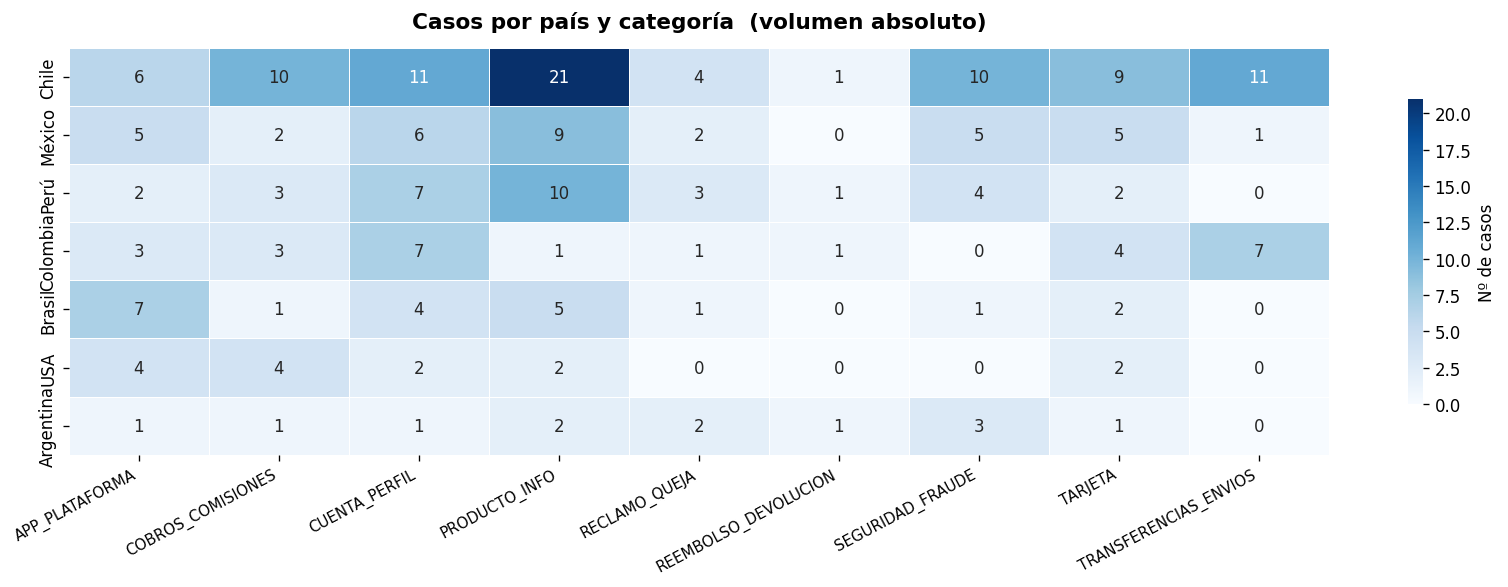

In [186]:
# Heatmap 3: Distribución geográfica por categoría (volumen absoluto) ---
# Filtramos países con al menos 5 casos para que el heatmap sea legible

top_countries = (
    res_clean["pais"].value_counts()
    .loc[lambda x: x >= 5]
    .index.tolist()
)

geo = (
    res_clean[res_clean["pais"].isin(top_countries)]
    .groupby(["pais", "category"])
    .size()
    .unstack(fill_value=0)
)
geo = geo.loc[geo.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    geo,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Nº de casos", "shrink": 0.75},
)
ax.set_title("Casos por país y categoría  (volumen absoluto)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=28, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

Brasil concentra el 30% de sus casos en `APP_PLATAFORMA`, siendo esta la proporción más alta de todos los mercados y probablemente relacionada con problemas de idioma. Colombia y Perú muestran una concentración inusual en `CUENTA_PERFIL`, lo que podría reflejar mayores fricciones en el proceso de verificación de datos personales en esos mercados. Chile, como mercado principal, tiene volumen distribuido en todas las categorías, lo que hace más difícil priorizar sin este tipo de segmentación.

Con esto en mente, pasamos a construir el **mapa de riesgo consolidado**, que combina sentimiento y urgencia en un único índice para visualizar el posicionamiento relativo de cada categoría.

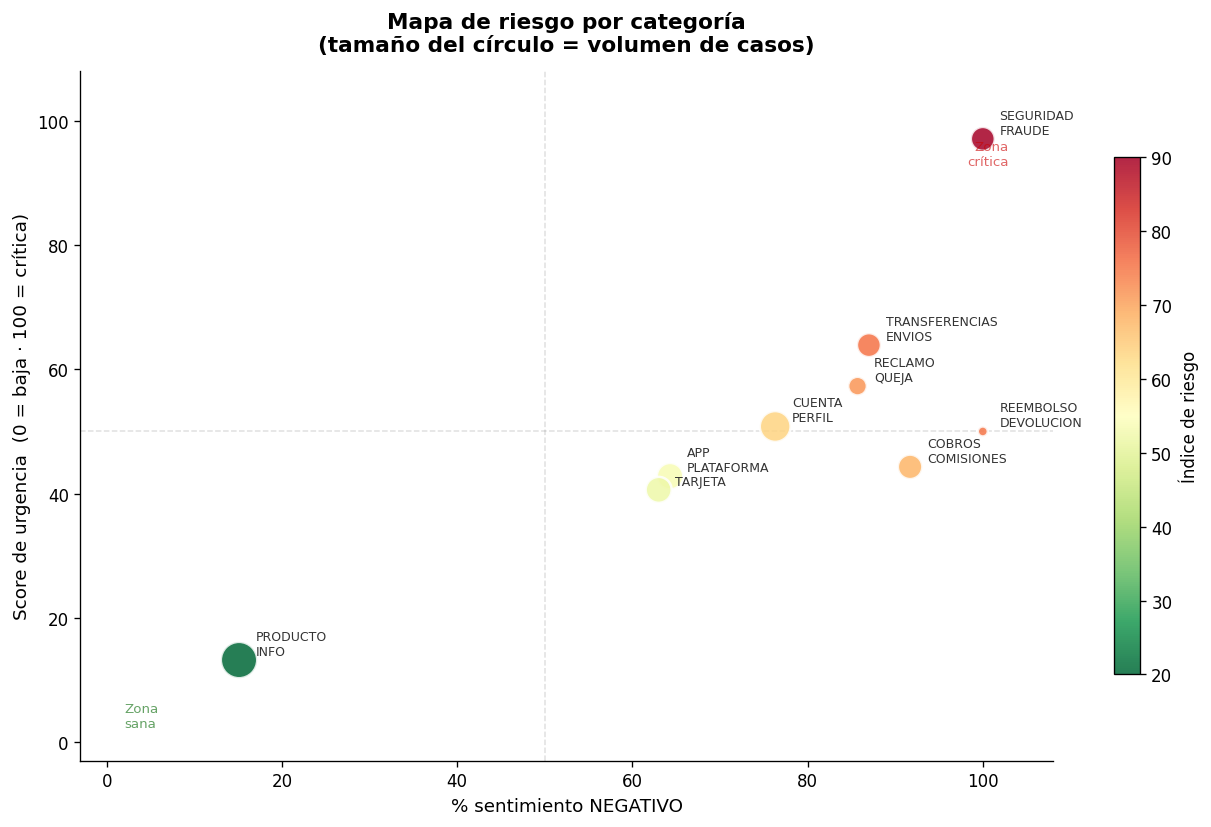


Índice de riesgo por categoría (ordenado):
             category  pct_negativo  urg_score  risk_index  n_casos
     SEGURIDAD_FRAUDE         100.0       97.1        98.6       23
TRANSFERENCIAS_ENVIOS          87.0       63.9        75.4       23
 REEMBOLSO_DEVOLUCION         100.0       50.0        75.0        4
        RECLAMO_QUEJA          85.7       57.3        71.5       14
    COBROS_COMISIONES          91.7       44.3        68.0       24
        CUENTA_PERFIL          76.3       50.8        63.6       38
       APP_PLATAFORMA          64.3       42.8        53.6       28
              TARJETA          63.0       40.6        51.8       27
        PRODUCTO_INFO          15.1       13.2        14.1       53


In [187]:
# Mapa de riesgo: sentimiento vs urgencia por categoría ---
# Risk index: 50% % NEGATIVO + 50% urgencia ponderada (BAJA=0, MEDIA=0.33, ALTA=0.67, CRITICA=1.0)

urgency_weights = {"BAJA": 0.0, "MEDIA": 0.33, "ALTA": 0.67, "CRITICA": 1.0}

risk_data = []
for cat, group in res_clean.groupby("category"):
    n = len(group)
    pct_neg    = (group["sentiment"] == "NEGATIVO").sum() / n * 100
    urg_score  = group["urgency"].map(urgency_weights).mean() * 100
    risk_index = pct_neg * 0.5 + urg_score * 0.5
    risk_data.append({
        "category":    cat,
        "pct_negativo": round(pct_neg, 1),
        "urg_score":    round(urg_score, 1),
        "risk_index":   round(risk_index, 1),
        "n_casos":      n,
    })

risk_df = pd.DataFrame(risk_data).sort_values("risk_index", ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    risk_df["pct_negativo"],
    risk_df["urg_score"],
    s=risk_df["n_casos"] * 9,
    c=risk_df["risk_index"],
    cmap="RdYlGn_r",
    vmin=20, vmax=90,
    alpha=0.85,
    edgecolors="white",
    linewidths=1.5,
    zorder=3,
)

for _, row in risk_df.iterrows():
    label = row["category"].replace("_", "\n")
    ax.annotate(
        label,
        (row["pct_negativo"], row["urg_score"]),
        textcoords="offset points",
        xytext=(10, 3),
        fontsize=7.5,
        color="#333333",
    )

plt.colorbar(sc, ax=ax, label="Índice de riesgo", shrink=0.75)

ax.axvline(50, color="gray", linestyle="--", alpha=0.25, linewidth=0.9)
ax.axhline(50, color="gray", linestyle="--", alpha=0.25, linewidth=0.9)
ax.text(103,  97, "Zona\ncrítica", ha="right", va="top",    fontsize=8, color="#cc0000", alpha=0.6)
ax.text(  2,   2, "Zona\nsana",   ha="left",  va="bottom", fontsize=8, color="#006600", alpha=0.6)

ax.set_xlim(-3, 108)
ax.set_ylim(-3, 108)
ax.set_xlabel("% sentimiento NEGATIVO", fontsize=11)
ax.set_ylabel("Score de urgencia  (0 = baja · 100 = crítica)", fontsize=11)
ax.set_title(
    "Mapa de riesgo por categoría\n(tamaño del círculo = volumen de casos)",
    fontsize=13, fontweight="bold", pad=12
)

plt.tight_layout()
plt.show()

print("\nÍndice de riesgo por categoría (ordenado):")
print(risk_df[["category", "pct_negativo", "urg_score", "risk_index", "n_casos"]].to_string(index=False))

## 4. Conclusiones



El análisis nos permite identificar con claridad los **puntos débiles prioritarios** de la operación de soporte de Global66:

### Weak Points Críticos (acción inmediata)

1. **`SEGURIDAD_FRAUDE`**, entendido como `Incidentes de seguridad que afectan la cuenta o tarjeta del usuario, incluyendo accesos no autorizados, phishing, clonacion de tarjeta, transacciones fraudulentas y perdida o robo de dispositivos.` 
    - 100% sentimiento negativo + 96% urgencia crítica. 
    - Es el único tema donde la velocidad de respuesta tiene impacto directo en el daño financiero del usuario. 
    - Automatizar la primera respuesta (bloqueo de cuenta, tarjeta) y escalar de forma inmediata sería un buen plan de acción.

2. **`TRANSFERENCIAS_ENVIOS`**, entendido como `Consultas y problemas relacionados con envios de dinero nacionales e internacionales, incluyendo demoras, rechazos, errores en datos del destinatario y devoluciones de fondos.`
    - Core del negocio con el 81% de los casos en urgencia ALTA o CRÍTICA. 
    - Cuando el envío falla, los usuarios escalan rápido y el "espera 48h hábiles" no es suficiente. 
    - Se requieren respuestas proactivas y trazabilidad en tiempo real.

3. **`RECLAMO_QUEJA`**, entendido como `Quejas formales del usuario, amenazas de accion regulatoria o legal, mala atencion al cliente e incumplimiento de plazos o promesas. Categoria clave para detectar alertas de riesgo reputacional y regulatorio.`
    - 100% negativo con presencia de amenazas regulatorias explícitas (SERNAC, SBS).
    - Es la señal de alarma reputacional más clara del dataset.

### Weak Points Secundarios (acción planificada)

4. **`COBROS_COMISIONES`**, entendido como `Reclamos y consultas sobre cobros inesperados, comisiones, tipo de cambio, cargos duplicados, suscripciones no deseadas y ajustes de saldo no autorizados.`
    - 88% negativo. La raíz no es el cobro en sí, sino la percepción de falta de transparencia 
    — `TIPO_CAMBIO` es la subcategoría más frecuente y los usuarios sienten que la tasa "se mueve" justo al confirmar.

5. **`CUENTA_PERFIL > VERIFICACION_IDENTIDAD`**, entendido como `Problemas con el proceso de validacion de identidad incluyendo selfie, documentos de identificacion, reconocimiento facial o validacion de datos personales.`
    - Subcategoría más frecuente de todo el dataset (16 casos). 
    - El proceso de KYC genera fricción.
    - Foco crítico para mejorar la tasa de onboarding.

### Lo que funciona, pero podría ahorrar tiempo humano

- **`PRODUCTO_INFO`**, entendido como `Consultas informativas sobre productos y servicios de Global66, incluyendo funcionalidades de la cuenta, documentacion, billetera multimoneda, medios de pago y disponibilidad en nuevos mercados.`
    - 63% de sus casos son NEUTRAL o POSITIVO, con urgencia predominantemente BAJA. 
    - Las consultas informativas se resuelven bien
    - Una base de conocimiento entrenada podría absorber gran parte de este volumen sin intervención humana.

# 5. Next Steps

En base a las conclusiones obtenidas, se procede ahora a escoger uno de los problemas detectados y proponer una automatización que elimine la causa raíz. El problema detectado es el que categorizamos como `SEGURIDAD_FRAUDE`: `Incidentes de seguridad que afectan la cuenta o tarjeta del usuario, incluyendo accesos no autorizados, phishing, clonacion de tarjeta, transacciones fraudulentas y perdida o robo de dispositivos.`

### 5.1. Razonamiento de la elección.

¿Por qué `SEGURIDAD_FRAUDE`?

Es el único problema donde el tiempo de detección tiene impacto financiero directo. La brecha de 48h que describe el enunciado es potencialmente catastrófica, pues en 48h un atacante ya vació la cuenta. Y si un usuario pidió ayuda urgente y se le respondió cuando ya todo ocurrió, este se convierte con alta probabilidad en **detractor de la plataforma**, el tipo de usuario que comparte su testimonio y/o inicia acciones legales. Nuestro objetivo será evitar eso.

Las señales, a su vez, complementan la decisión. Los datos muestran 100% sentimiento NEGATIVO y 96% urgencia CRÍTICA, describiendo conversaciones bastante particulares. Esto da paso a un patrón lingüístico - "me clonaron la tarjeta", "ayuda me robaron la cuenta" - que no se solapará con facilidad con otros problemas, permitiendo así alcanzar una alta precisión en el flujo sin necesidad de mayor ingeniería de prompt.

 Por otro lado, mientras otras opciones como  `TRANSFERENCIAS_ENVIOS` no tienen un "next step" evidente con el contexto de negocio que tenemos, en `SEGURIDAD FRAUDE` es fácil diseñar un flujo razonable:
  - Ejecutar una tool para bloquear los movimientos en la cuenta,
  - Escalar al equipo de fraude con prioridad CRÍTICA,
  - Responder automáticamente al usuario con instrucciones inmediatas ("Acabamos de bloquear tu cuenta. A fin de reestablecer tu servicio de forma segura, sigue estos pasos ...")

  Así mismo, el costo del falso positivo (un bloqueo porque el agente malinterpretó una solicitud de soporte) es órdenes de magnitud menor que el costo del estado actual (usuario pide que le bloqueen la cuenta, pasan 48h y recién entonces se atiende su caso).


¿Por qué no alguno de los otros problemas detectados?

A continuación lo analizamos uno por uno. 

- Candidato: `TRANSFERENCIAS_ENVIOS`
- Problema: Las acciones requieren integración con entidades bancarias. Es difícil delegar ese aspecto en un LLM con el contexto que manejamos actualmente.
  
- Candidato: `COBROS_COMISIONES`
- Problema: La causa raíz es de producto/UX, no de automatización. Una API no resuelve que la tasa fluctúa.

- Candidato: `RECLAMO_QUEJA`
- Problema: Solo 13 casos (5.2%). Bajo volumen relativo.
  
- Candidato: `VERIFICACION_IDENTIDAD`
- Problema: Interesante para impacto en onboarding, pero no encaja con el contexto de "alerta en tiempo real" solicitado por el enunciado.

**Entonces, ¿Cuál es el problema raíz a resolver?**

El problema raíz a resolver es que no existe una primera línea de defensa que monitoree mensajes entrantes en tiempo real. El 90% no se revisa manualmente, y el 10% que sí se revisa llega tarde. Para un escenario de fraude, llegar tarde implica daño real, lo cual nos lleva a perder un usuario y ganar un posible detractor.

## 5.2. Arquitectura propuesta y escalabilidad

Para este caso diseñaremos una API en FastAPI, la cual servirá un agente construido mediante el ADK de Anthropic. El agente recibirá mensajes de soporte y ejecutará una lógica muy similar a la que vimos en este notebook, categorizando las conversaciones y, si es que caen en el caso seleccionado, tendrá la capacidad de activar un flujo de emergencia, respondiendo al usuario de forma correspondiente. De lo contrario, simplemente guardará la clasificación, permitiendo que el ticket de soporte siga su flujo actual.

Dicha API se entregará en dos formatos:
- Como un paquete de código deployeable de forma local, con persistencia en `.csv` 
- Como servicio en la nube de Google (GCP), donde se desplegará a través de Cloud Run Services, guardando la API Key de Anthropic en Secret Manager. **Esto nos permitirá que nuestro servicio escale de forma segura y económica (10,10 USD por mes para una API con ~1M de request al mes y trafico pulsar** - Véase [Calculadora de GCP para Cloud Runs](https://cloud.google.com/products/calculator?hl=es&dl=CjhDaVExTUdVNU9HSmhPQzB3WlRBMUxUUXhaREV0WWprME1TMWtPR1ZrWm1Rek9HSTFaRGtRQVE9PRAcGiRBQUJGMTkzOS0xQjAyLTQ4RjItOUQyRi01MzMxMkM4MTUwQUE)). 
- Por otro lado, nos ocuparemos de que el agente incorpore `prompt_caching`, para así asegurarnos de que mensajes duplicados -que podría ocurrir, por ejemplo, si un usuario manda su misma solicitud urgente por distintos canales - no nos lleven a incurrir en mayor consumo de tokens.
- En el caso de la API deployeada en GCP, propondremos también el almacenamiento de las consultas y su historial en BigQuery, lo cual nos permitirá realizar analítica posterior. Esta parte solo se propone mas no se implementa.

Desde luego, esta solución será extensible: si bien en este caso nos limitaremos al problema de Fraude, el agente podría evolucionar incorporando también RAGs para consultas informativas, otras tools para otros tipos de problemas, etc. 

A continuación se presenta un diagrama de arquitectura para la solución a desarrollar.

![assets/architecture.png](assets/architecture.png)

### 5.3. Uso de la API

La API servirá el endpoint `/sofia/classify`, el cual recibirá un JSON Payload como el descrito a continuación:

```json
{
    "case_id": "CASE-001",
    "message_id": "MSG-001",
    "user_id": "USR-772",
    "direction": "INBOUND",
    "text": "hola, me robaron ...",
    "platform": "instagram",
    "pais_usuario": "Chile",
}
```
La API responderá con un JSON indicando la decisión tomada para cada mensaje:

```json
{
    "case_id": "CASE-001",
    "message_id": "MSG-001",
    "decision": "keep_hearing",
    "sentiment": "POSITIVO",
    "category": "DESCONOCIDO",
    "subcategory": "DESCONOCIDO",
    "urgency": "BAJA",
    "text": "",
}
# O bien
{
    "case_id": "CASE-001",
    "message_id": "MSG-001",
    "decision": "trigger_block",
    "sentiment": "NEGATIVO",
    "category": "SEGURIDAD_FRAUDE",
    "subcategory": "ACCESO_NO_AUTORIZADO",
    "urgency": "CRITICAL",
    "text": "Para tu seguridad, hemos desactivado temporalmente tu cuenta. A continuación, ...",
}
```

Donde:
- `keep_hearing` representa delegar en flujo tradicional. Este caso no lleva `†ext` pues nuestro agente no interviene, pero sigue escuchando próximas interacciones.
- `trigger_block` representa triggerear el bloqueo de la cuenta. Este caso lleva `text` que corresponde a la intervención del agente para dar aviso al usuario de que su cuenta fue bloqueada y de los próximos pasos a seguir. 

**URL API Deployeada**: `https://sofia-901545252597.europe-west1.run.app`
Endpoints:
- GET `/health`
- POST `/sofia/classify`
- GET `/sofia/memory`
- DELETE `/sofia/classify/{case_id}`

